# Práctica 13: Imágenes y animaciones

En esta práctica se revisaran algunas funciones de MATLAB® que permiten la manipulación de archivos que contienen imágenes, para su visualización y análisis como variables. Además de su despliegue en figuras nativas, es decir, como elementos gráficos, es posible almacenar los componentes básicos en espacios de memoria en un formato de arreglos o matrices, lo cual permite la descomposición de las imágenes en los componentes de colores básicos rojo, azul y verde, además de su manipulación usando muchas de las importantes herramientas del álgebra lineal. En esta práctica se tratará con los imágenes representadas usando los colores primario Rojo, Verde y Azul, que son la base del estandard o formato RGB para la representación de imágenes en dispositivos electrónicos como lo son las computadoras y las pantallas de los sistemas inteligentes.

La unidad básica para la representación de las imágenes es el pixel, un pixel es entendido como una célula de una imágen. Una imágen se compone de miles o millones de estas unidades fundamnetales que a su vez se conforman de los tres colores primarios rojo, verde y azul, dado que la combinación de estos tres colores permite generar una amplia gama de colores y así representar imágenes. A cada pixel se le asignan tres variables que representan la intensidad de rojo, verde y azul en la imagen en ese punto en específico, en un rango de 0 a 255.



In [1]:
clear 
close all
clc
R=zeros(600);
G=R;
B=R;
R(1:end,1:200)=255;
G(1:end,201:400)=255;
B(1:end,401:600)=255;
rgbimg=cat(3,R,G,B);

[A]= imread("micrófono.png");
%[A]= imread("retrato.tif");
%[A]= imread("Imagen.jpg");
%[A]= imread("Grafica_python.png");
%A=imread("https://raw.githubusercontent.com/LuisGerardo2204/Archivos_de_datos/refs/heads/main/juguete.png");
[A]= imread("juguete.png");
whos A
%[A]=cat(3,R,G,B); 

  Name        Size                 Bytes  Class    Attributes

  A         659x621x3            1227717  uint8              



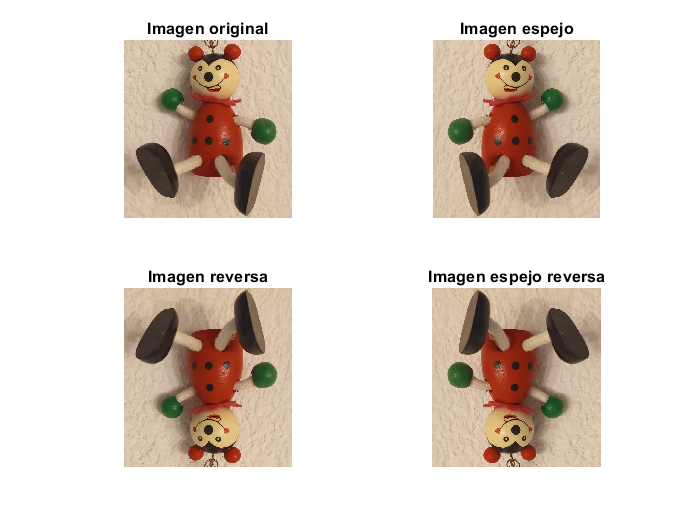

In [2]:
imagen_espejo=flipdim(A,2);
imagen_reversa=flipdim(A,1);
imagen_espejo_reversa=flipdim(imagen_reversa,2);

figure
subplot(2,2,1)
imshow(A)
title("Imagen original")
subplot(2,2,2)
imshow(imagen_espejo)
title("Imagen espejo")
subplot(2,2,3)
imshow(imagen_reversa)
title("Imagen reversa")
subplot(2,2,4)
imshow(imagen_espejo_reversa)
title("Imagen espejo reversa")



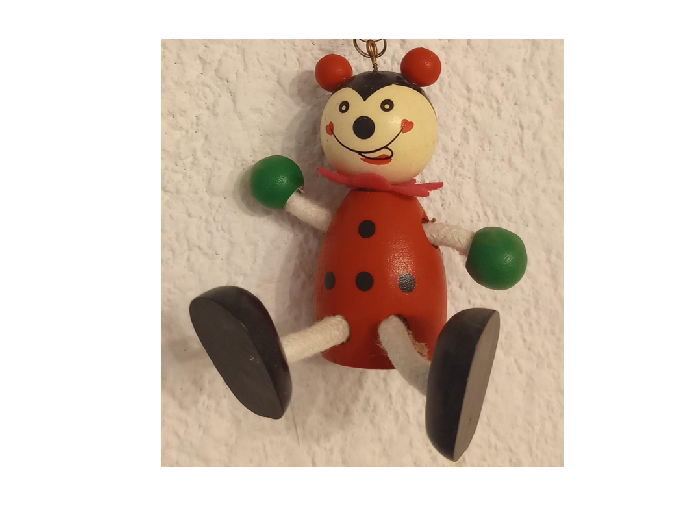

In [3]:
Rojo = A(:,:,1); 
Verde = A(:,:,2); 
Azul = A(:,:,3);

figure
imshow(cat(3, Rojo, Verde, Azul))

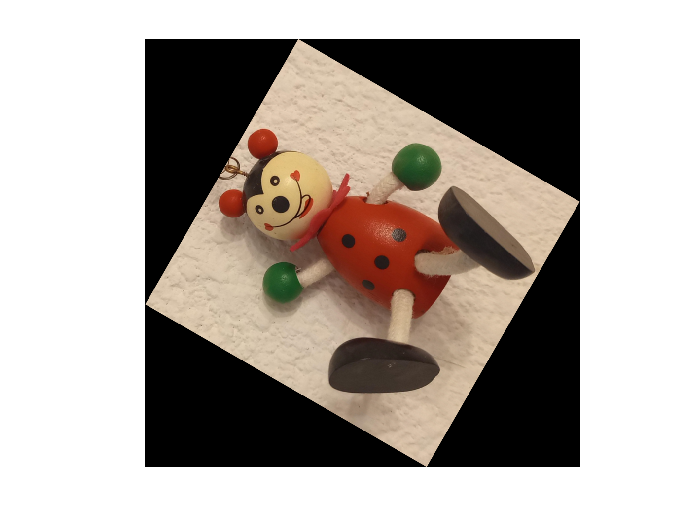

In [4]:
imagen_rotada=imrotate(A,60,"Bilinear");
figure
imshow(imagen_rotada)

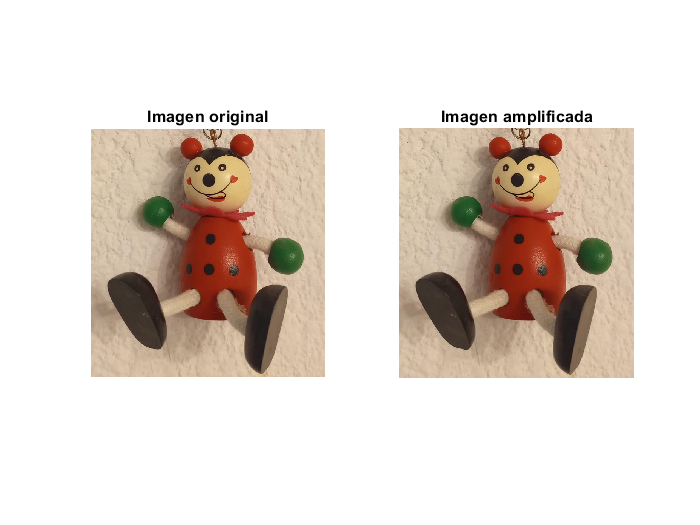

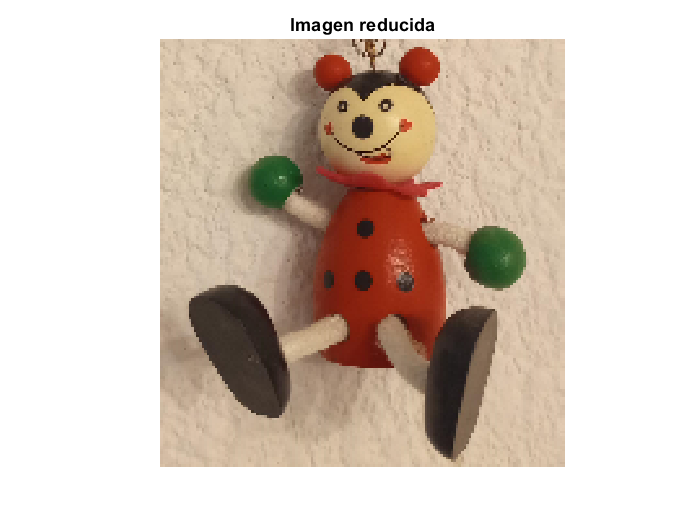

In [5]:
imagen_amplificada=imresize(A,20,"nearest");
imagen_reducida=imresize(A,0.25,"nearest");
figure
subplot(1,2,1)
imshow(A)
title("Imagen original")
subplot(1,2,2)
imshow(imagen_amplificada)
title("Imagen amplificada")
figure
imshow(imagen_reducida)
title("Imagen reducida")

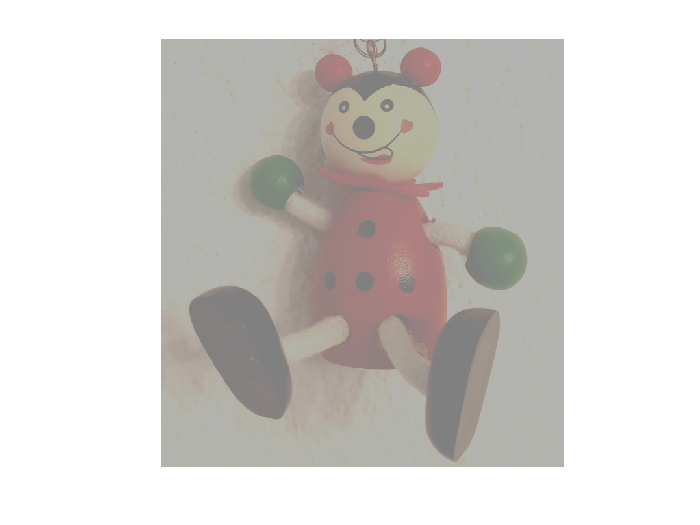

In [6]:

figure
imagen_ajustada_manual=imadjust(A, [0.2; 0.7],[0.5; 0.7]);
imshow(imagen_ajustada_manual)


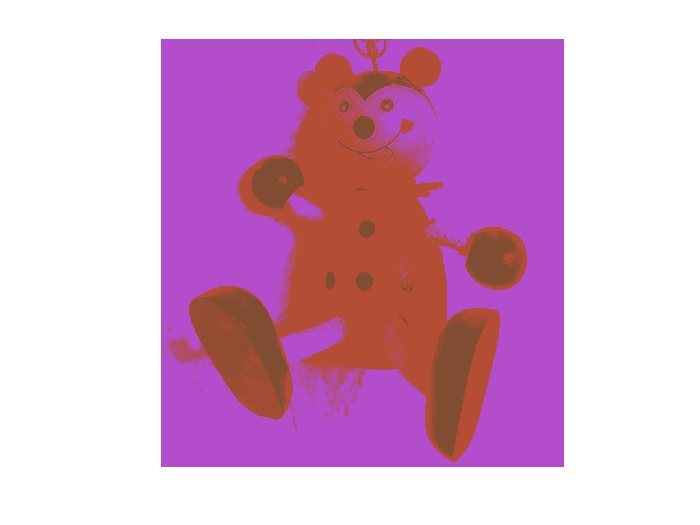

In [7]:
imagen_ajustada_RGB=imadjust(A, [0.2 0.3 0.4; 0.3 0.4 0.5],[0.5 0.3 0.2; 0.7 0.3 0.8]);
imshow(imagen_ajustada_RGB)

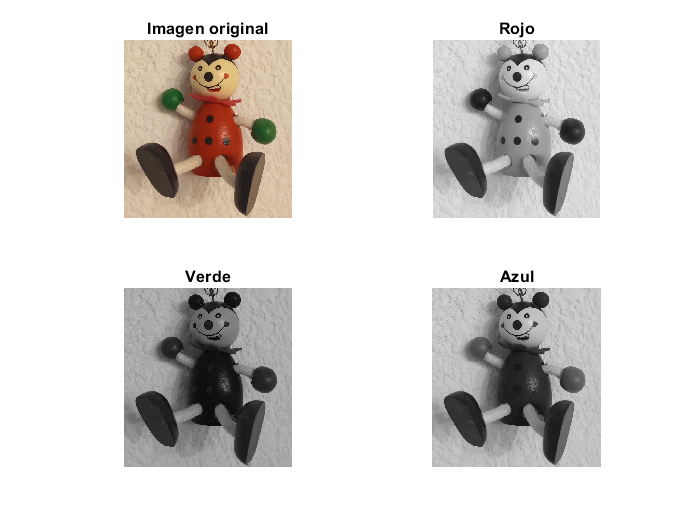

In [8]:
Rojo=A(:,:,1);
Azul=A(:,:,2);
Verde=A(:,:,3);

figure
subplot(2,2,1)
imshow(A)
title("Imagen original")
subplot(2,2,2)
imshow(Rojo)
title("Rojo")
subplot(2,2,3)
imshow(Verde)
title("Verde")
subplot(2,2,4)
imshow(Azul)
title("Azul")

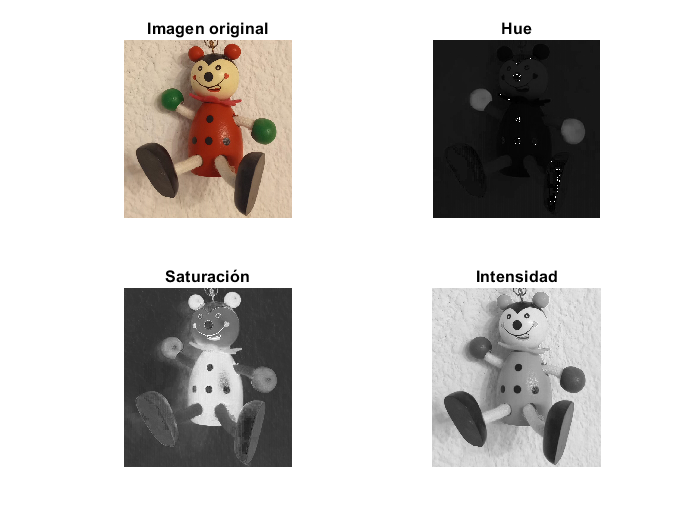

In [9]:
HSI=rgb2hsv(A);
figure
subplot(2,2,1)
imshow(A)
title("Imagen original")
subplot(2,2,2)
imshow(HSI(:,:,1))
title("Hue")
subplot(2,2,3)
imshow(HSI(:,:,2))
title("Saturación")
subplot(2,2,4)
imshow(HSI(:,:,3))
title("Intensidad")


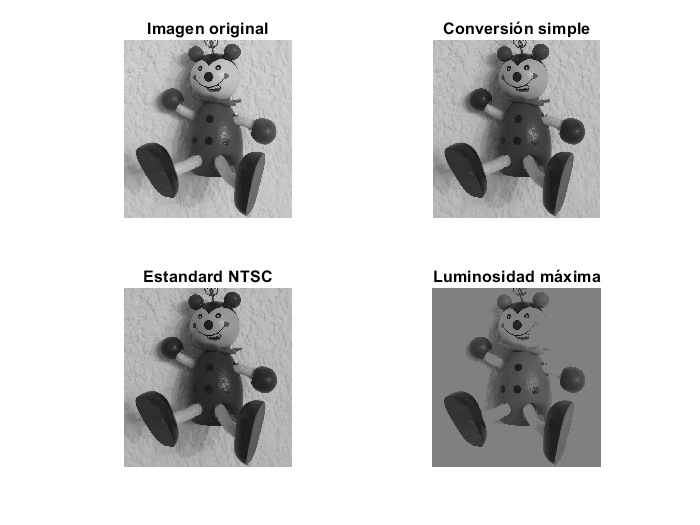

In [10]:
RGB_grises=rgb2gray(A);
RGB_grises2=0.299*Rojo+0.587*Verde+0.114*Azul;
RGB_grises3=0.21*Rojo+0.72*Verde+0.07*Azul;
RGB_grises4=(max(A,[],3)+min(A,[],3))/2;
figure
subplot(2,2,1)
imshow(RGB_grises)
title("Imagen original")
subplot(2,2,2)
imshow(RGB_grises2)
title("Conversión simple")
subplot(2,2,3)
imshow(RGB_grises3)
title("Estandard NTSC")
subplot(2,2,4)
imshow(RGB_grises4)
title("Luminosidad máxima")


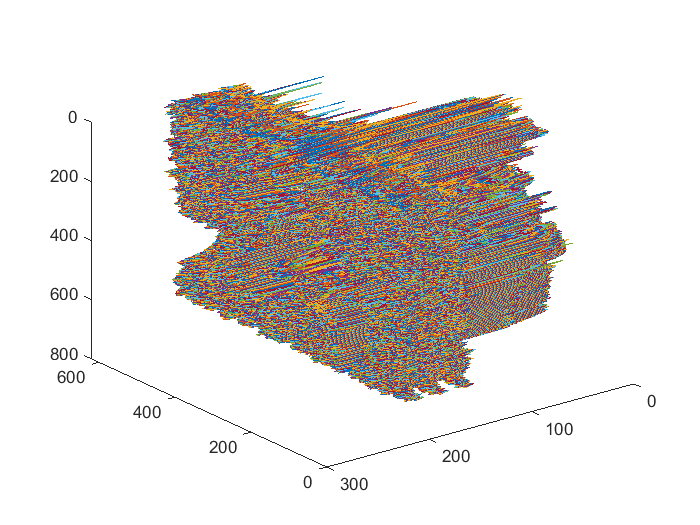

In [11]:
figure
hold on
for k=1:min(size(A))
   for i=max(size(A(:,1,k))):-1:1
       plot3(A(i,:,k),[max(size(A(i,:,k))):-1:1],i*ones(size(A(i,:,k))))
    end
end
view(3)
set(gca,'Xdir','reverse','Zdir','reverse')

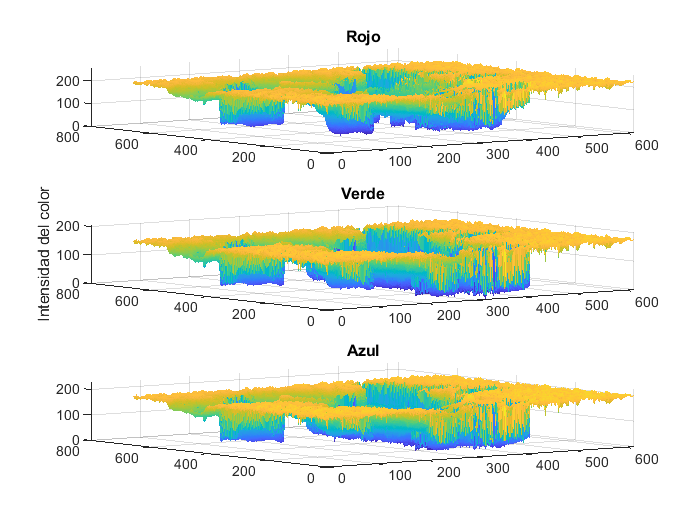

In [12]:

[r,c,j]=size(A); 
%surf(1:c,1:r,Rojo,'EdgeColor','none'); 
figure
subplot(3,1,1)
surf(1:c,1:r,Rojo,'EdgeColor','none'); 
title("Rojo")
view(3)
subplot(3,1,2)
surf(1:c,1:r,Verde,'EdgeColor','none'); 
zlabel('Intensidad del color')
view(3)
title("Verde")
subplot(3,1,3)
surf(1:c,1:r,Azul,'EdgeColor','none'); 
title("Azul")
view(3)
%set(gca,'Zdir','reverse','Ydir','reverse')
%surf(1:c,1:r,Verde,'EdgeColor','none'); 
%set(gca,'Zdir','reverse','Ydir','reverse')


## Animación de funciones

Es posible realizar la animación de funciones en las gráficas generadas con MATLAB®, con el fin de integrar dinámica visual a los resultados numéricos que representan las gráficas de las funciones. Una de las formas de generar animaciones es generar una gráfica que se atualice cada cierto intervalo. Los siguientes ejemplos muestran la forma de generar animaciones de dos casos clásicos en física, el movimiento rectilíneo y el oscilador armónico.

### Movimiento rectilíneo

El movimiento rectilíneo es aquel que se puede representar en el plano usando una sola coordenada. Esta coordenada se modela como una función del tiempo y describe el movimiento de una partícula en términos de su posición respecto de un marco de referencia fíjo y su velocidad y aceleración definidas como:

* $x(t)=$ posición en metros.
* $v(t)=\frac{dx(t)}{dt}=$velocidad en $[m/s]$.
* $a(t)=\frac{dx^2(t)}{dt^2}=$ aceleración en $m/s^2$.

El siguiente ejemplo permite generar la animación de un movimiento rectilíneo que describe una trayectoria oscilatoria en el eje $x$, descrito por la expresión:

$$
x(t)=4.5sen(2t)~~[m]
$$

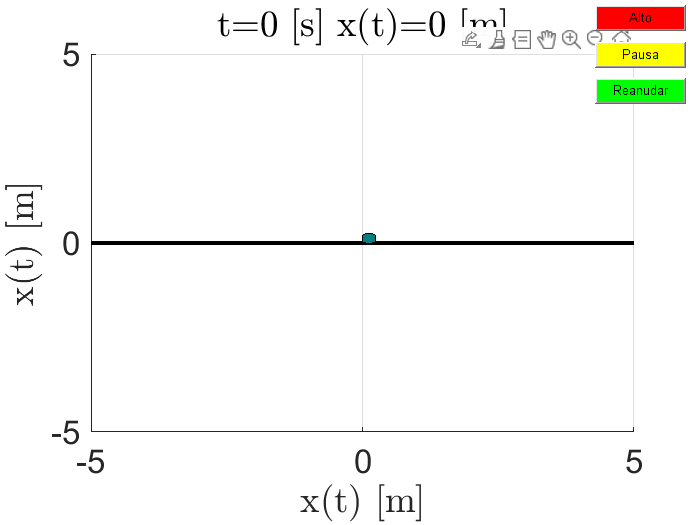

In [13]:
clear 
 close all
 clc


t=0:0.001:6;


xt=4.5*sin(2*t);

uno=figure;
grid


axis([-5 5,-5 5])


  handle=uicontrol('style','pushbutton','units','normal','backgroundcolor','red','position', ...
            [0.85 .94 .13 .05],'String','Alto','callback','global stopstop;stopstop=1;'); 
  handle2=uicontrol('style','pushbutton','units','normal','backgroundcolor','yellow','position', ...
            [0.85 .87 .13 .05],'String','Pausa','callback','global ppause;ppause=1;');
  handle3=uicontrol('style','pushbutton','units','normal','backgroundcolor','green','position', ...
            [0.85 .8 .13 .05],'String','Reanudar','callback','global ppause;ppause=0;');

            
set(gca,'defaulttextinterpreter','latex')
  
   set(get(gca,'XLabel'),'String','x(t) [m]',...
                    'FontName','Arial',...
                    'FontAngle','normal',...
                    'FontSize',20)
% 
 set(get(gca,'YLabel'),'String','x(t) [m]',...
                     'FontName','Arial',...
                     'FontAngle','normal',...
                     'FontSize',20)

 
set(gca,'fontsize',20);
set(gca,'fontname','Arial','FontWeight','normal');  

global stopstop ppause;
ppause=0;
i=1;
stopstop =0;

  while( i<5000&&stopstop==0)
    
     cla
     
     title(strcat('t= ',num2str((i-1)*0.001),' [s]','    x(t)= ',num2str(xt(i)),' [m]'))
     hold on
     plot([-5:0.001:5],0*[-5:0.001:5],'k -','LineWidth',2)
     plot(t(1:i),xt(1:i),'b -','LineWidth',2)
    rectangle('Position',[xt(i) 0.0 0.24 0.24],'FaceColor',[0 .5 .5],'Curvature',0.5)
    pause(0.001)
   
                while ppause==1
                    pause(.001)
                  
                end
        i=i+10;       
       cla
                  
    end
    close(uno)



### Sistema oscilador armónico.

Un sistema masa-resorte-amortiguador se considera como un oscilador armónico y se modela matemáticamente usando la ecuación diferencial:

```{math}
:label: modelo1
\begin{equation}
  m\frac{d^2y(t)}{dt^2}+b\frac{dx(t)}{dt}+ky(t)=f(t)
	\end{equation}
```
Donde $y(t)$ es la solución de la ecuación diferencial {eq}`modelo1` y representa al desplazamiento en metros de la masa $m$ respecto del punto de equilibrio, $m$ es la masa en $[kg]$, $b$ la constante de amortiguador con unidades $[Ns/m]$ y $k$ en unidades $[N/m]$. además $f(t)$ es la fuerza externa. En una práctica posterior se retomará este modelo para hacer simulaciones en el entorno gráfico simulink®.

La solución general para el caso de vibraciones libres, es decir, cuando $f(t)=0$ y por lo menos alguna de las condiciones iniciales de posición $x(0)$ en $[m]$ o velocidad $v(0)$ en $[m/s]$ es 

```{math}
:label: solgen
\begin{equation}
  y(t)=e^{-\frac{b}{2m}t}(x(0)cos(\omega_{d}t)+\betasen(\omega_{d}t))
	\end{equation}
```
donde $\omega_d$ y $\beta$ son la frecuencia natural mortiguada y $\beta$ una constante dadas por: 

$$
\omega_d=\sqrt{\frac{k}{m}-\frac{b^2}{4m^2}},~~~~\beta=\frac{mv(0)+bx(0)}{m\omega_d}
$$

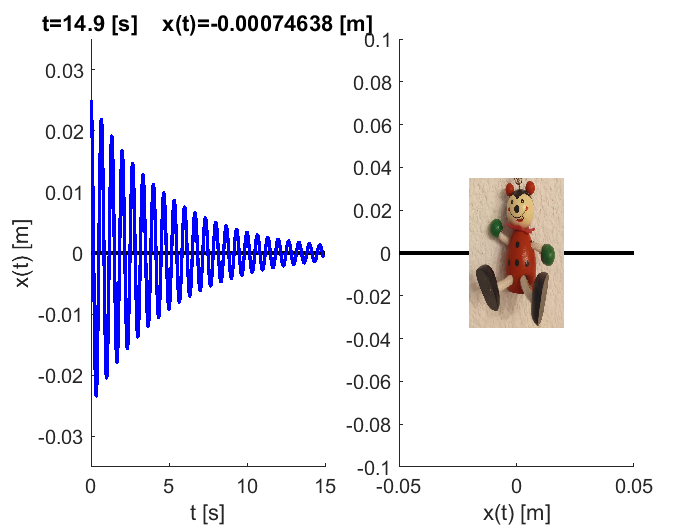

In [17]:
clear 
close all
clc

A=imread("https://raw.githubusercontent.com/LuisGerardo2204/Archivos_de_datos/refs/heads/main/juguete.png");

m=0.43;
b=0.15;
k=4.5;
x0=0.025;
dx0=0.0;

wd=sqrt(k/m-b^2/(4*m^2));

a=(m*dx0+b*x0)/(m*wd);


t=0:0.001:15;

F1=exp((-b/(2*m)).*t).*(x0*cos(wd.*t)+a*sin(wd.*t));

xt=F1;


dos=figure;
global stopstop ppause;

i=1;

while((i<max(t)*1000))
    
     cla
    
     subplot(1,2,1)
     hold on
       plot([-max(t):0.001:max(t)],0*[-max(t):0.001:max(t)],'k -','LineWidth',2)
      plot(t(1:i),xt(1:i),'b -','LineWidth',2)
      axis([0 max(t),-0.035 0.035])
      
  
      set(get(gca,'XLabel'),'String','t [s]',...
                    'FontName','Arial',...
                    'FontAngle','normal',...
                    'FontSize',12)
% 
     set(get(gca,'YLabel'),'String','x(t) [m]',...
                     'FontName','Arial',...
                     'FontAngle','normal',...
                     'FontSize',12)

    set(gca,'fontsize',12);
    set(gca,'fontname','Arial','FontWeight','normal');  
    title(strcat('t= ',num2str((i-1)*0.001),' [s]','    x(t)= ',num2str(xt(i)),' [m]'))
    
   
       
    subplot(1,2,2)
     hold on
     plot([-max(t):0.001:max(t)],0*[-max(t):0.001:max(t)],'k -','LineWidth',2)
     image([-0.02 0.02],[xt(i)+0.035 xt(i)-0.035],A);   
     axis([-0.05 0.05,-0.1 0.1])
     set(get(gca,'XLabel'),'String','x(t) [m]',...
                    'FontName','Arial',...
                    'FontAngle','normal',...
                    'FontSize',12)
     set(gca,'fontsize',12);
     set(gca,'fontname','Arial','FontWeight','normal');  
                
   i=i+100;       
   pause(0.01)
   cla
                  
end     

subplot(1,2,2)
hold on
plot([-max(t):0.001:max(t)],0*[-max(t):0.001:max(t)],'k -','LineWidth',2)
image([-0.02 0.02],[0.035 -0.035],A); 
     axis([-0.05 0.05,-0.1 0.1])
set(get(gca,'XLabel'),'String','x(t) [m]',...
                    'FontName','Arial',...
                    'FontAngle','normal',...
                    'FontSize',12)
set(gca,'fontsize',12);
set(gca,'fontname','Arial','FontWeight','normal');  

## Ejercicio de la prática 14

1.- Descargue o lea desde la ruta las siguientes imágenes:

https://raw.githubusercontent.com/LuisGerardo2204/Archivos_de_datos/refs/heads/main/flores.JPG
https://raw.githubusercontent.com/LuisGerardo2204/Archivos_de_datos/refs/heads/main/cedral.jpg

Realice las siguientes operaciones con las dos imágenes:

a) En una figura muestre la imagen original, la imagen en escala de grises, la imagen invertida y la imagen escalada al 25% de su tamaño original.

b) En otra figura muestre la imagen original y su versión con un filtro `imgaussfilt()`.

c) En una tercer figura muestre la imagen original y la figura con las transformaciones:

$$
Y= 0.3R+0.6G+0.114*B,~~~~I=-0.5R-0,3G+0.4B,~~~~~Q=0.7R-0.52G-0.12B
$$

donde $R$ es la matriz componente rojo, $B$ es la matriz componente azul y $G$ es la matriz componente verde. Use el comando `imshow(cat(3,Y,I,Q))` para mostrar la imagen transformada.

2.- Realice la animación de la gráfica $y(t)$ para un sistema masa-resorte con condiciones iniciales $y(0)=0.015~[m]$, velocidad inicial $v(0)=0~[m/s]$, masa $m=0.5~[kg]$ y constante de rigidez $k=300~[N/m]$. Considere que la ecuaciones {eq}`solgen` para construir la ecuación para simular el caso particular que se plantea.

3.- Realice la animación de la gráfica de uno de los casos del tiro parabólico del ejercicio 2 de la Práctica 9. 
